In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
df = pd.read_csv('../data/final_dataset.csv')
df.head()

,date,station,TMAX,state,id,elevation,disasters_count,heat_related_disaster_count,heat_related_area_count,heat_related_any,...,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum
0,2020-01-01,GHCND:USW00013876,56.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
1,2020-01-02,GHCND:USW00013876,70.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
2,2020-01-03,GHCND:USW00013876,65.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
3,2020-01-04,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
4,2020-01-05,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0


# Dimension Reduction (PCA)

In [8]:
X = df.select_dtypes(include=["number"]).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_


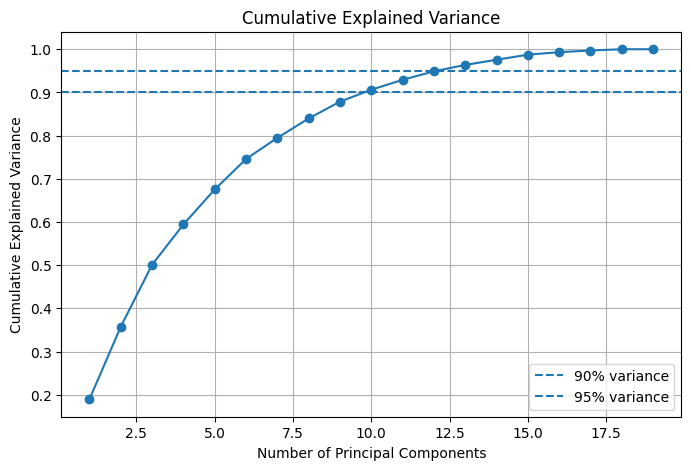

In [11]:
cumulative_var = explained_var.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.axhline(y=0.90, linestyle='--', label='90% variance')
plt.axhline(y=0.95, linestyle='--', label='95% variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

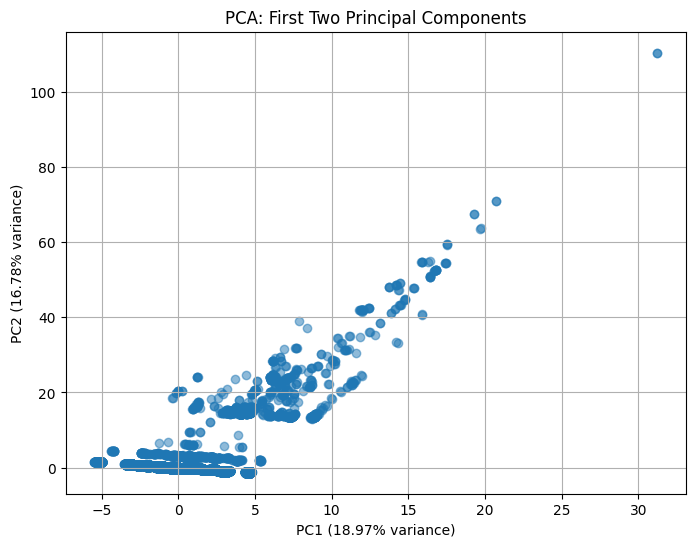

In [13]:
pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)

col_names = [f"PC{i}" for i in range(1, 11)]
pca_df = pd.DataFrame(pcs, columns=col_names)

plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.title("PCA: First Two Principal Components")
plt.grid(True)
plt.show()

# Statistical Analysis + Visualizations

In [17]:
num = df.select_dtypes(include=[np.number])

summary_stats = pd.DataFrame({
    "count": num.count(),
    "mean": num.mean(),
    "median": num.median(),
    "std": num.std(),
    "variance": num.var(),
    "min": num.min(),
    "q1": num.quantile(0.25),
    "q3": num.quantile(0.75),
    "max": num.max(),
    "skewness": num.skew(),
    "kurtosis": num.kurtosis(),
    "missing": num.isna().sum()
})

print(summary_stats.round(3))

                                 count         mean       median          std  \
TMAX                            196943       59.264       60.000       20.697   
elevation                       196943     1156.481      530.400     1073.839   
disasters_count                 196943        0.010        0.000        0.130   
heat_related_disaster_count     196943        0.007        0.000        0.093   
heat_related_area_count         196943        0.045        0.000        1.342   
heat_related_any                196943        0.006        0.000        0.077   
heat_related_counties_affected  196943        0.043        0.000        1.331   
state_fips                      196943       31.690       32.000       15.943   
p_pov                           196943       19.935       19.821        4.376   
p_unemp                         196943        4.739        4.311        1.042   
p_nohsdp                        196943        9.610        8.950        3.031   
p_uninsur                   

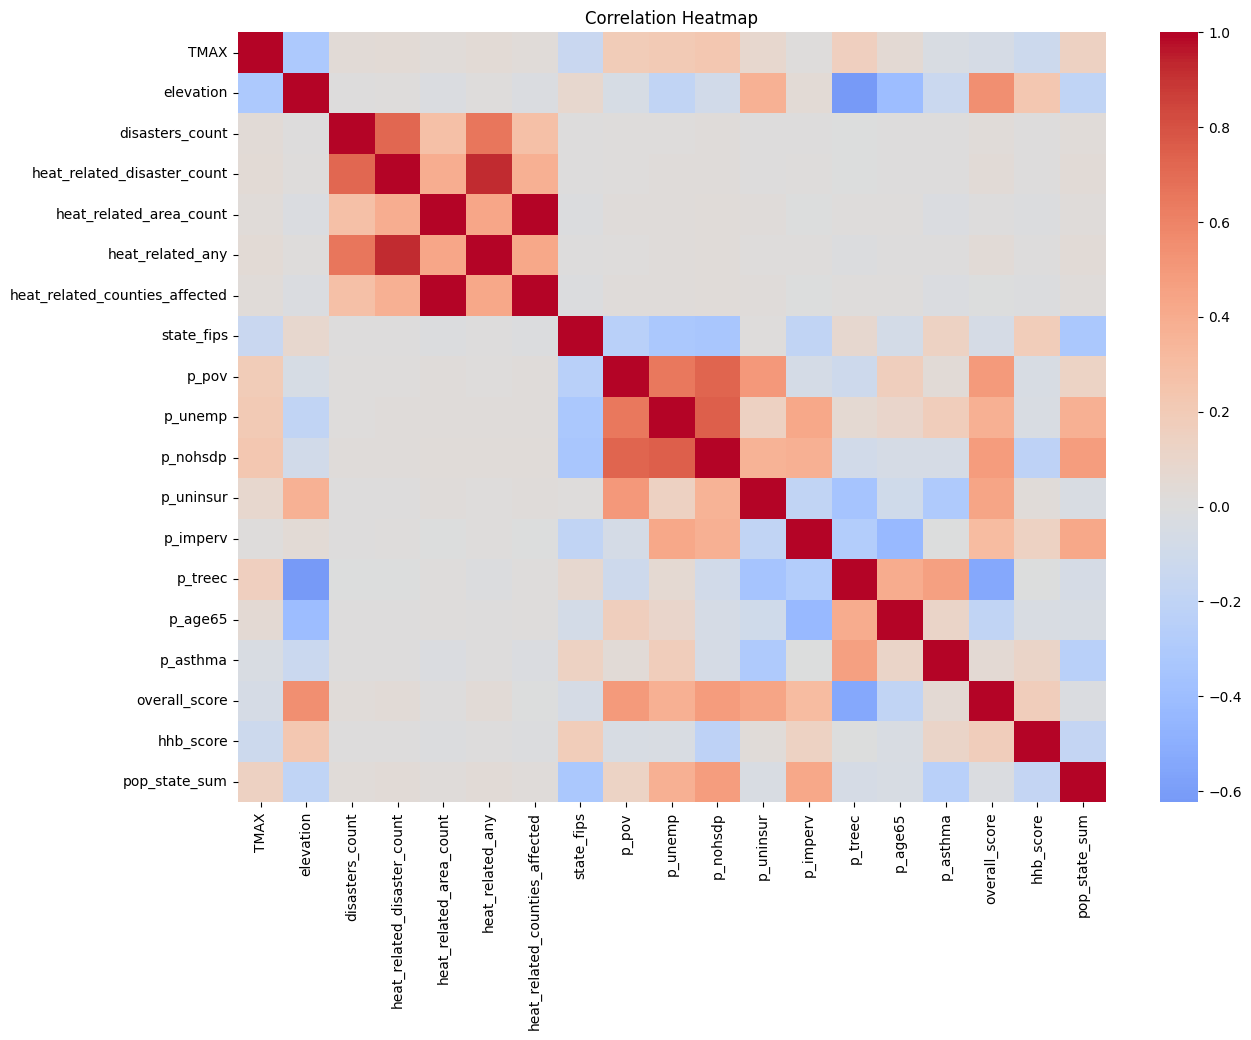

In [18]:
import seaborn as sns

corr = num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [21]:
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()

# remove duplicate pairs
corr_pairs["pair_key"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["feature_1"], row["feature_2"]])),
    axis=1
)
corr_pairs = corr_pairs.drop_duplicates("pair_key").drop(columns="pair_key")

top_corr = corr_pairs.sort_values("abs_corr", ascending=False)
bottom_corr = corr_pairs.sort_values("abs_corr", ascending=True)
print(top_corr.head(5))
print(bottom_corr.head(5))

                       feature_1                       feature_2  correlation  \
77       heat_related_area_count  heat_related_counties_affected     0.999240   
58   heat_related_disaster_count                heat_related_any     0.922758   
171                      p_unemp                        p_nohsdp     0.750627   
153                        p_pov                        p_nohsdp     0.728282   
38               disasters_count     heat_related_disaster_count     0.719206   

     abs_corr  
77   0.999240  
58   0.922758  
171  0.750627  
153  0.728282  
38   0.719206  
                       feature_1      feature_2  correlation  abs_corr
106             heat_related_any      hhb_score     0.000083  0.000083
70   heat_related_disaster_count      hhb_score     0.000126  0.000126
104             heat_related_any       p_asthma    -0.001138  0.001138
87       heat_related_area_count  overall_score    -0.001819  0.001819
52               disasters_count      hhb_score    -0.001858  

In [22]:
from scipy import stats

cols_to_check = [
    "TMAX",
    "elevation",
    "disasters_count",
    "heat_related_disaster_count",
    "heat_related_area_count",
    "heat_related_counties_affected",
    "p_pov",
    "p_unemp",
    "overall_score",
    "pop_state_sum"
]

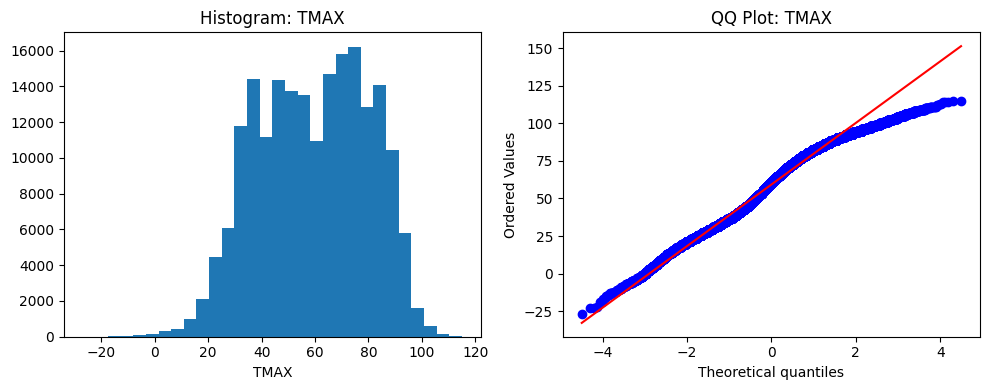

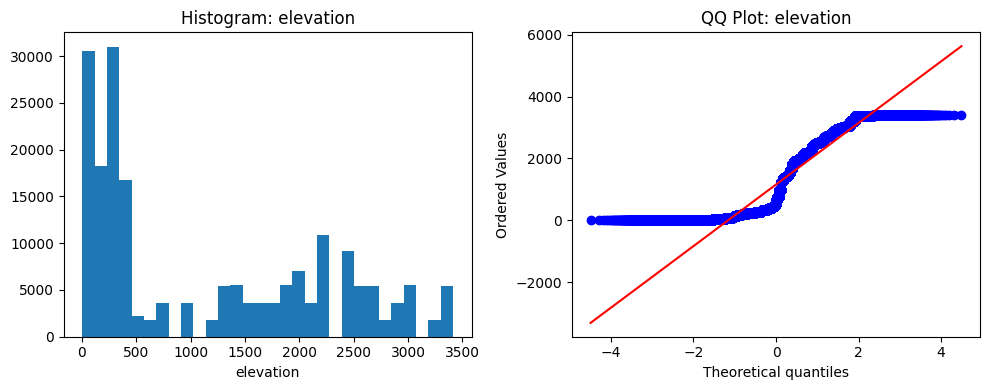

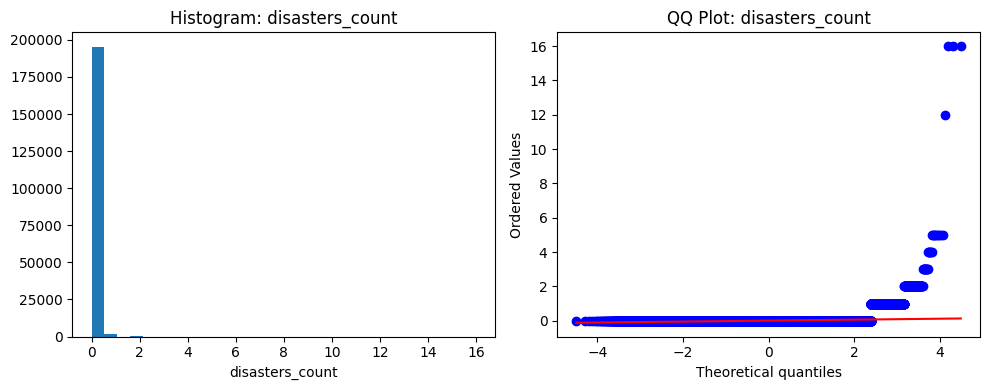

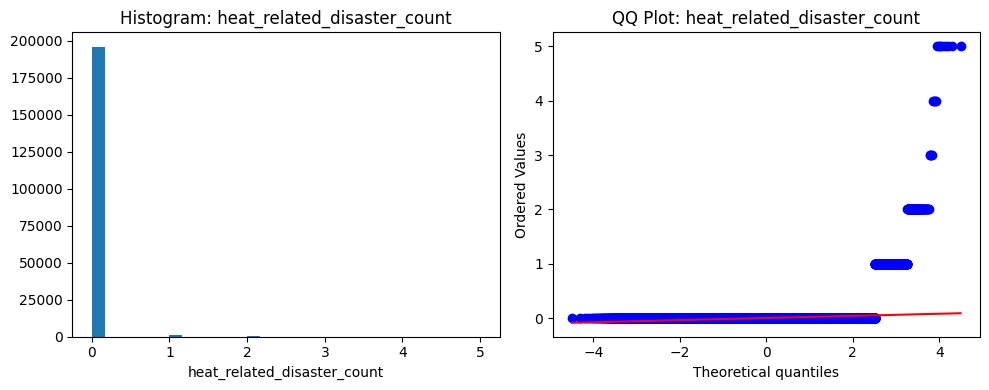

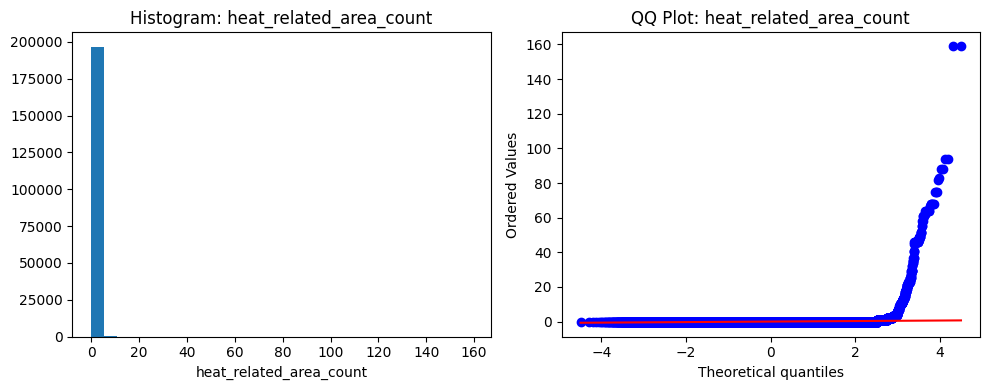

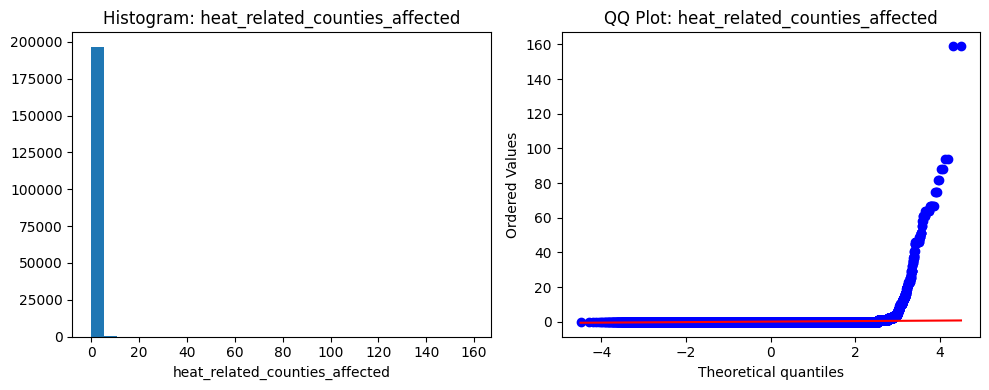

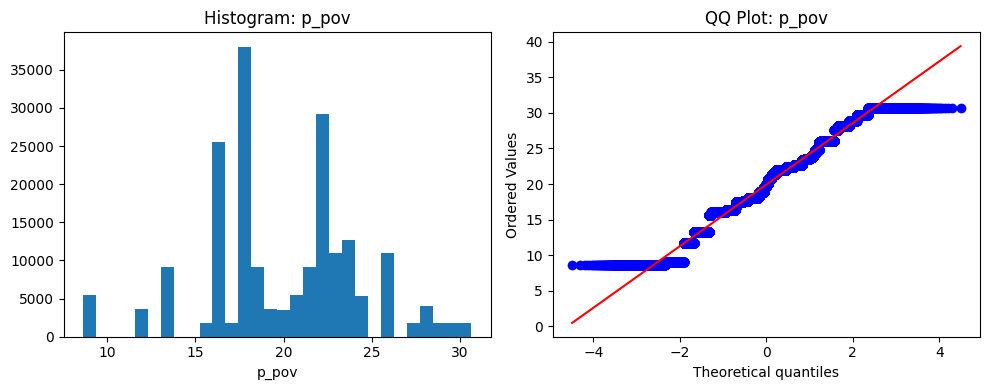

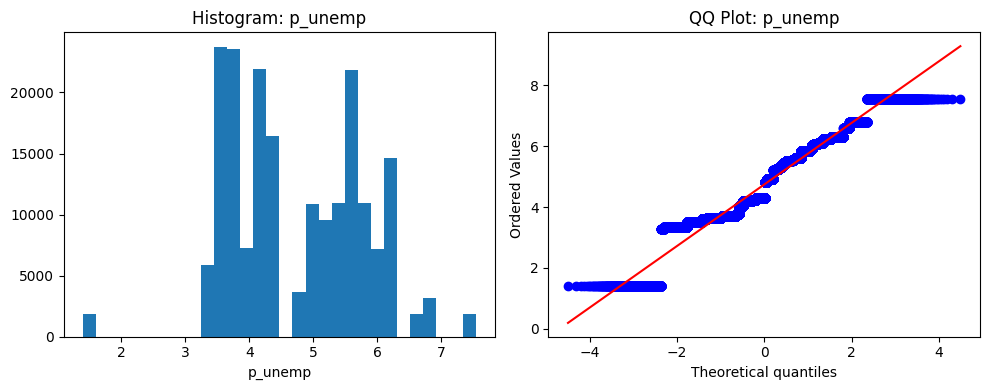

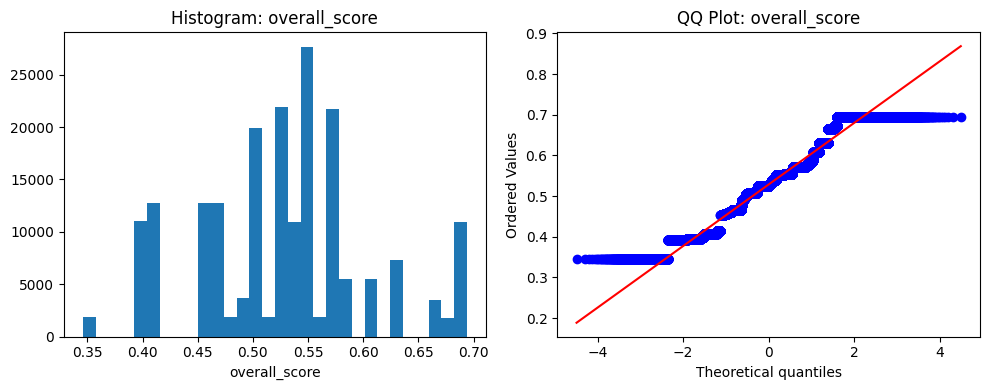

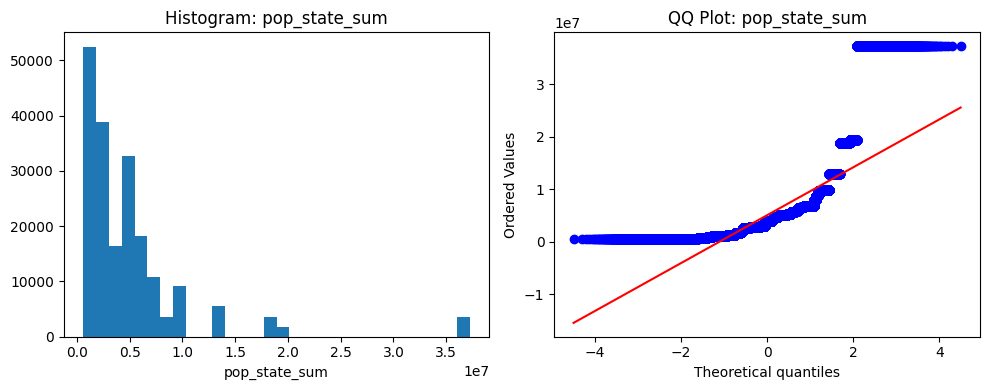

In [23]:
for col in cols_to_check:
    if col not in num.columns:
        continue

    x = num[col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(x, bins=30)
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)

    stats.probplot(x, dist="norm", plot=axes[1])
    axes[1].set_title(f"QQ Plot: {col}")

    plt.tight_layout()
    plt.show()

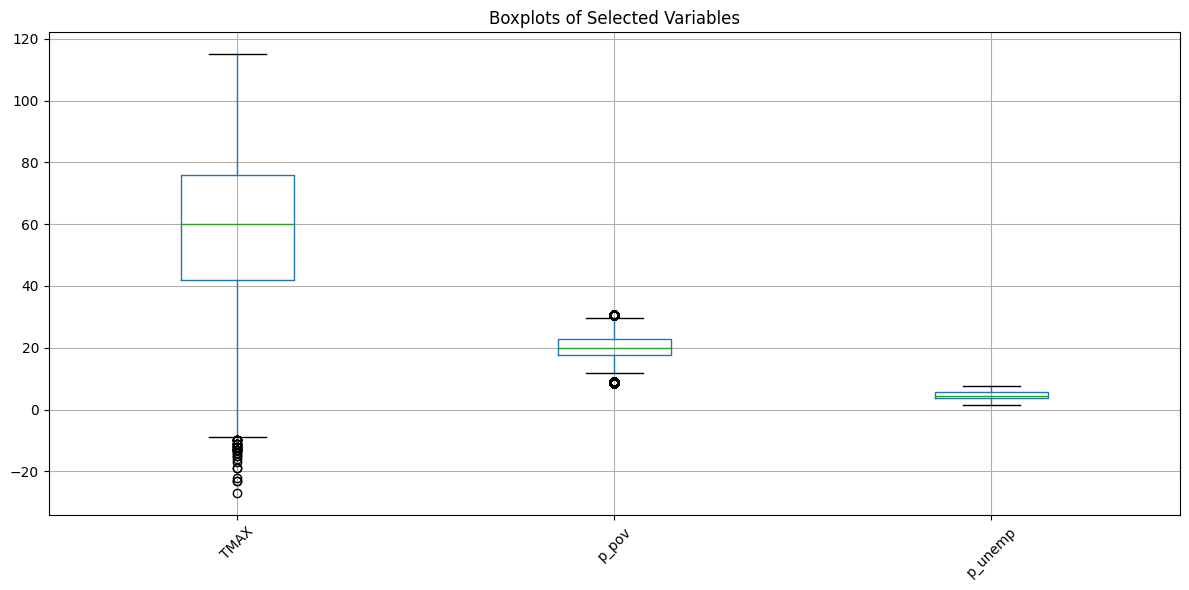

In [30]:
cols = [
    "TMAX", "p_pov",
    "p_unemp"
]

existing = [c for c in cols if c in df.columns]

plt.figure(figsize=(12, 6))
df[existing].boxplot(rot=45)
plt.title("Boxplots of Selected Variables")
plt.tight_layout()
plt.show()

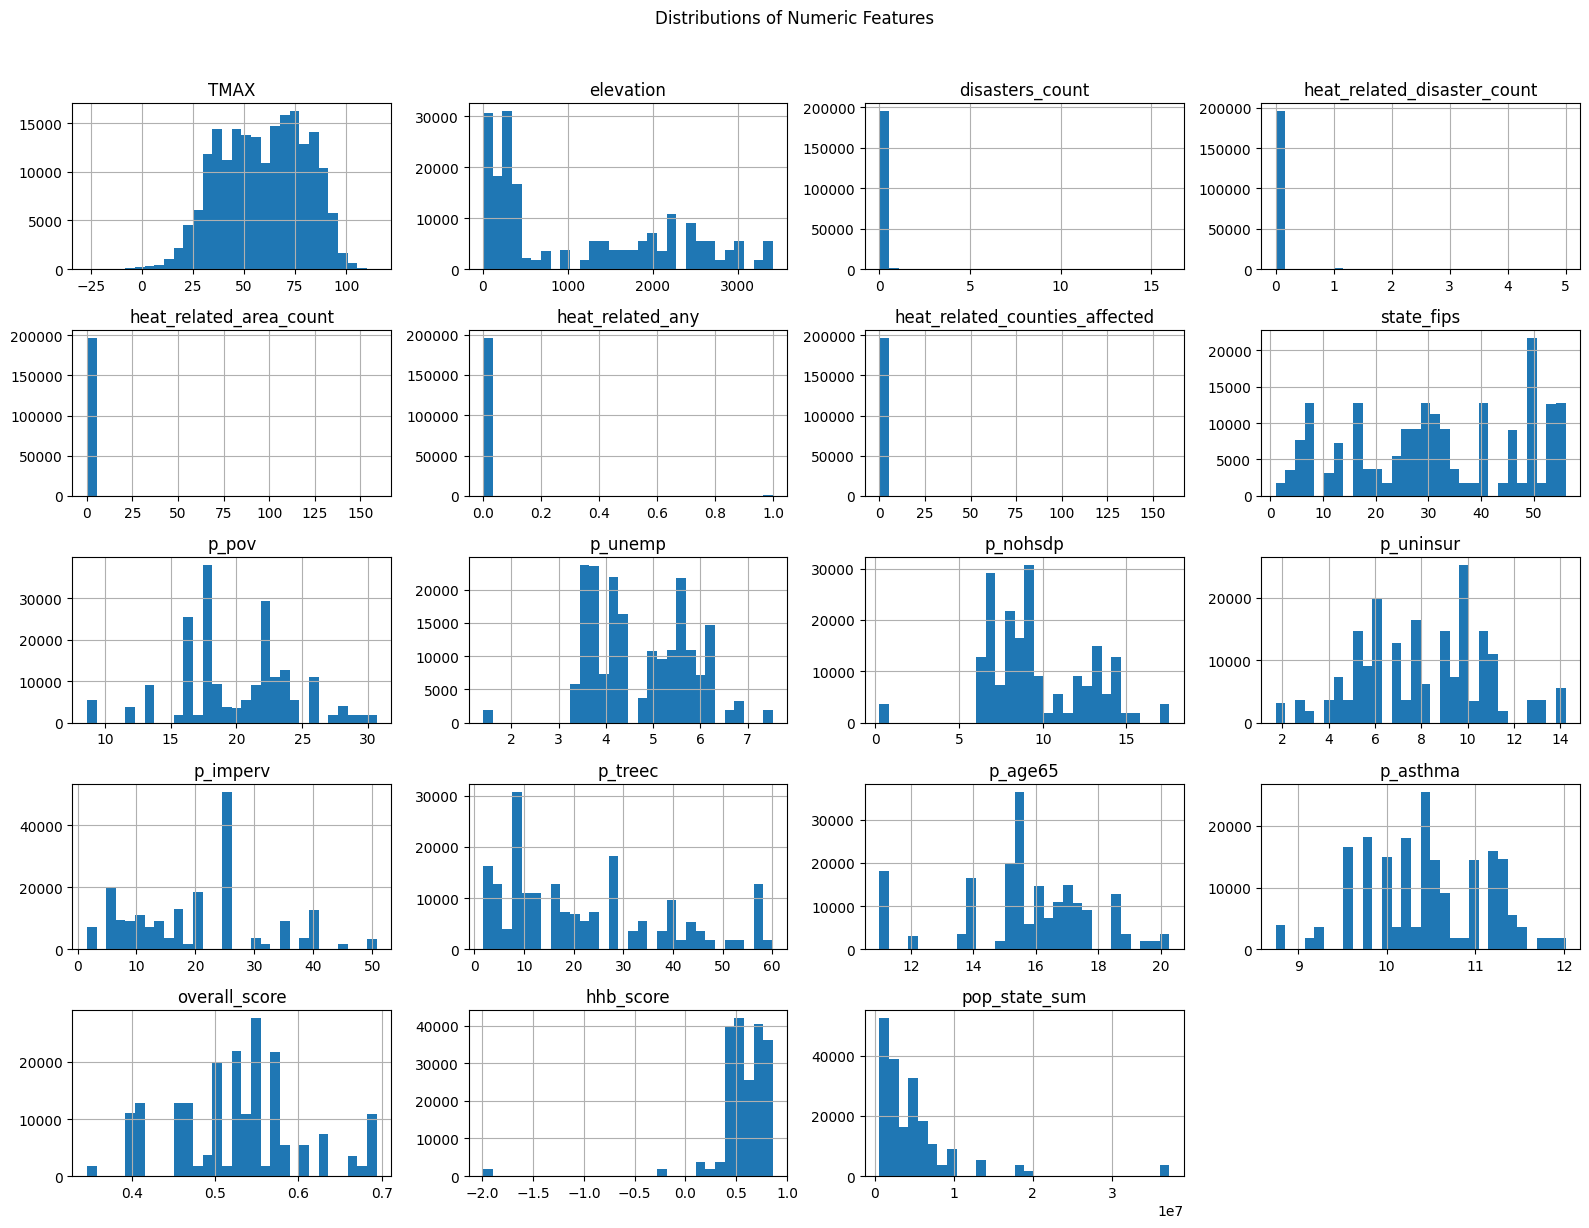

In [33]:
num.hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

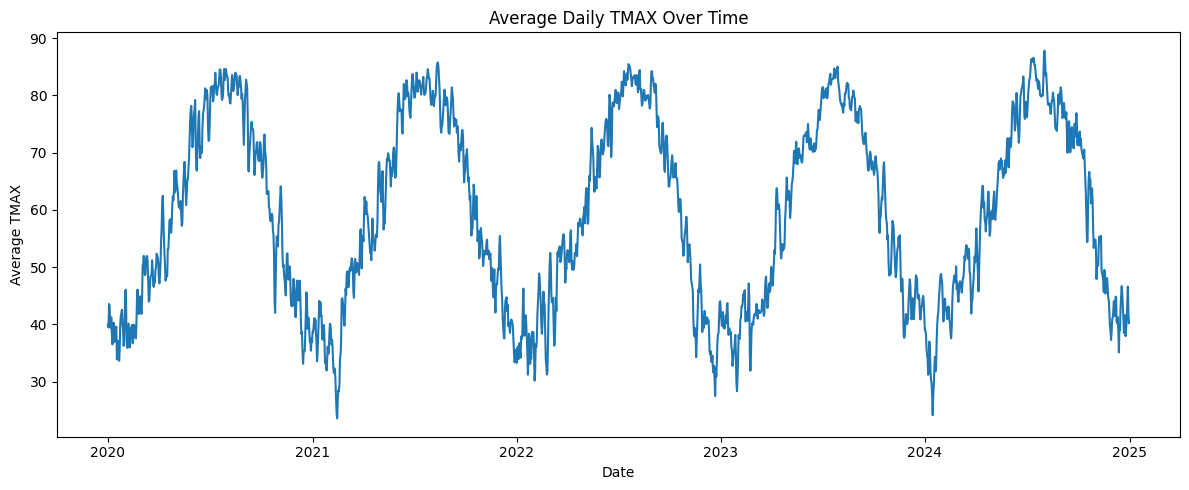

In [35]:
df["date"] = pd.to_datetime(df["date"])

daily_tmax = df.groupby("date")["TMAX"].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_tmax.index, daily_tmax.values)
plt.title("Average Daily TMAX Over Time")
plt.xlabel("Date")
plt.ylabel("Average TMAX")
plt.tight_layout()
plt.show()

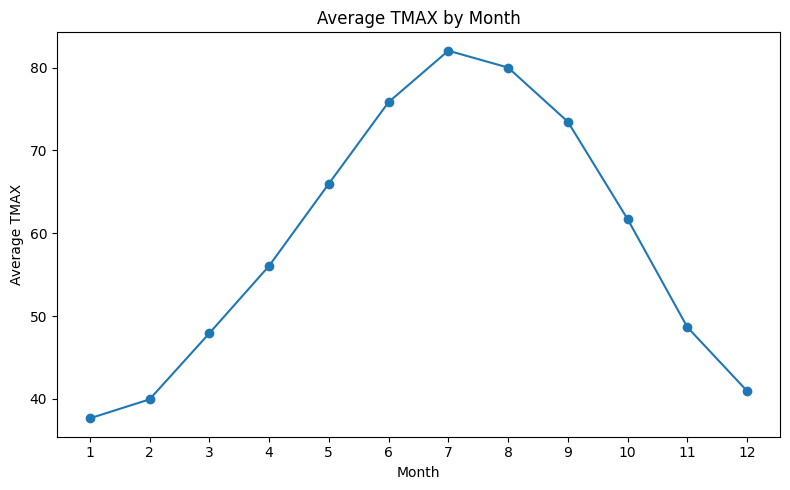

In [37]:
df["month"] = df["date"].dt.month

monthly_tmax = df.groupby("month")["TMAX"].mean()

plt.figure(figsize=(8, 5))
plt.plot(monthly_tmax.index, monthly_tmax.values, marker="o")
plt.title("Average TMAX by Month")
plt.xlabel("Month")
plt.ylabel("Average TMAX")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

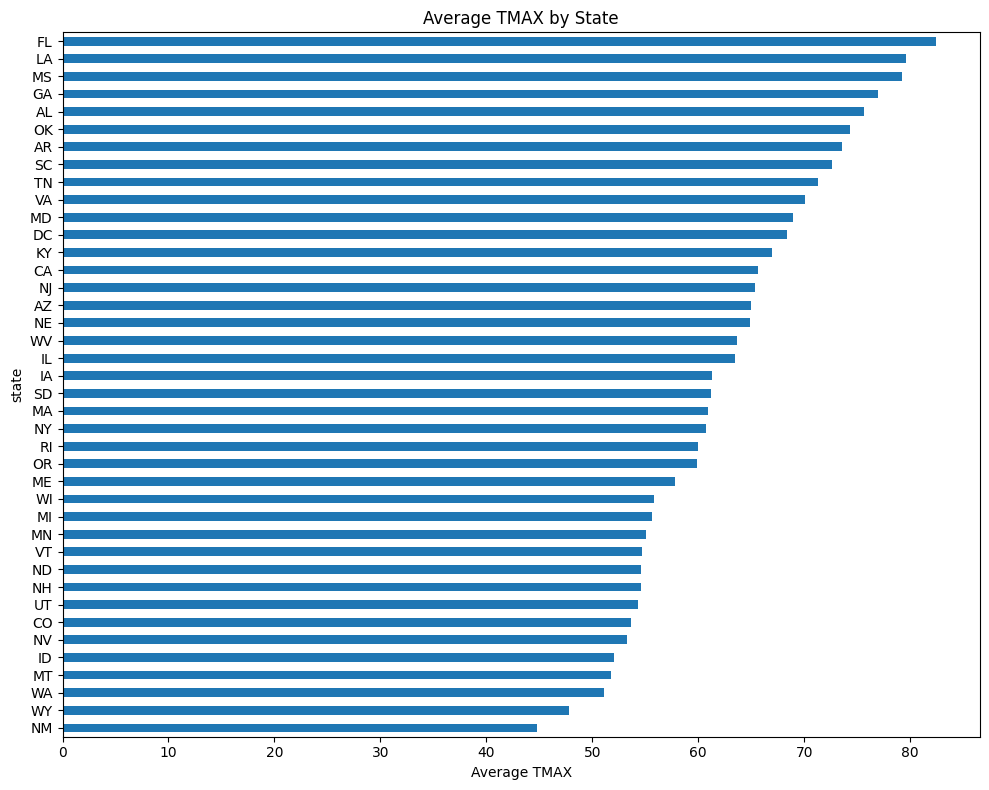

In [38]:
state_tmax = df.groupby("state")["TMAX"].mean().sort_values()

plt.figure(figsize=(10, 8))
state_tmax.plot(kind="barh")
plt.title("Average TMAX by State")
plt.xlabel("Average TMAX")
plt.tight_layout()
plt.show()

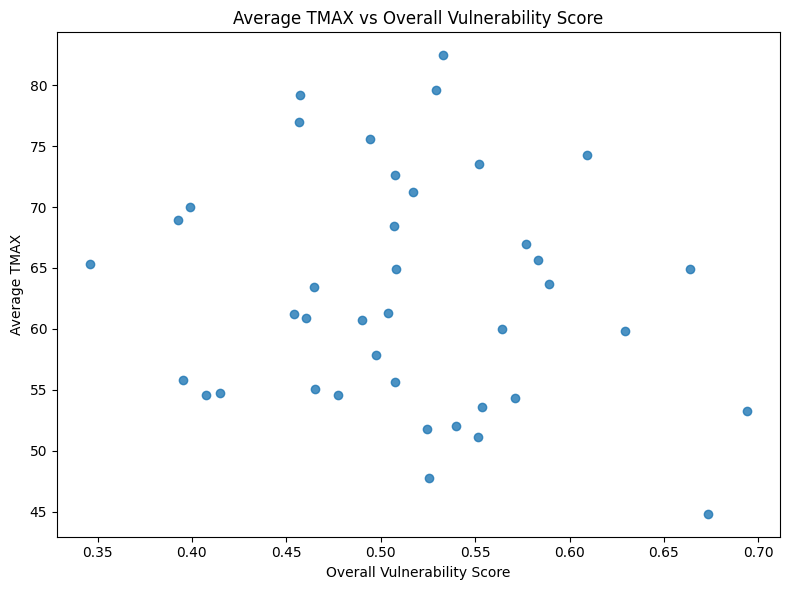

In [40]:
state_weather = df.groupby("state", as_index=False).agg({
    "TMAX": "mean",
    "overall_score": "first",
    "hhb_score": "first",
    "p_pov": "first"
})

plt.figure(figsize=(8, 6))
plt.scatter(state_weather["overall_score"], state_weather["TMAX"], alpha=0.8)
plt.xlabel("Overall Vulnerability Score")
plt.ylabel("Average TMAX")
plt.title("Average TMAX vs Overall Vulnerability Score")
plt.tight_layout()
plt.show()